# AIRLINE MARKET ENTRY ANALYSIS

## Imports and Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>Flights</b>: Contains route availability, distance, delays, and occupancy rates.

In [2]:
flights = pd.read_csv('data/Flights.csv')
print(flights.shape)
flights.head()

C:\Users\Steam\AppData\Local\Temp\ipykernel_47204\469840683.py:1: DtypeWarning: Columns (3,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('data/Flights.csv')


(1915886, 16)


,FL_DATE,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN,ORIGIN_CITY_NAME,DEST_AIRPORT_ID,DESTINATION,DEST_CITY_NAME,DEP_DELAY,ARR_DELAY,CANCELLED,AIR_TIME,DISTANCE,OCCUPANCY_RATE
0,2019-03-02,WN,N955WN,4591,14635,RSW,"Fort Myers, FL",11042,CLE,"Cleveland, OH",-8.0,-6.0,0.0,143.0,1025.0,0.97
1,2019-03-02,WN,N8686A,3231,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",1.0,5.0,0.0,135.0,930.0,0.55
2,2019-03-02,WN,N201LV,3383,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",0.0,4.0,0.0,132.0,930.0,0.91
3,2019-03-02,WN,N413WN,5498,14635,RSW,"Fort Myers, FL",11066,CMH,"Columbus, OH",11.0,14.0,0.0,136.0,930.0,0.67
4,2019-03-02,WN,N7832A,6933,14635,RSW,"Fort Myers, FL",11259,DAL,"Dallas, TX",0.0,-17.0,0.0,151.0,1005.0,0.62


<b>Tickets</b>: Contains sample ticket prices (use this for revenue calculations, but do not use it for occupancy).

In [3]:
tickets = pd.read_csv('data/Tickets.csv')
print(tickets.shape)
tickets.head()

(1167285, 12)


,ITIN_ID,YEAR,QUARTER,ORIGIN,ORIGIN_COUNTRY,ORIGIN_STATE_ABR,ORIGIN_STATE_NM,ROUNDTRIP,REPORTING_CARRIER,PASSENGERS,ITIN_FARE,DESTINATION
0,201912723049,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,736.0,DAB
1,201912723085,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,570.0,COS
2,201912723491,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,564.0,MCO
3,201912723428,2019,1,ABI,US,TX,Texas,1.0,MQ,1.0,345.0,LGA
4,201912723509,2019,1,ABI,US,TX,Texas,0.0,MQ,1.0,309.0,MGM


<b>Airport Codes</b>: Identifies airport size (Medium/Large) and location.

In [4]:
airports = pd.read_csv('data/Airport_Codes.csv')
print(tickets.shape)
airports.head()

(1167285, 12)


,TYPE,NAME,ELEVATION_FT,CONTINENT,ISO_COUNTRY,MUNICIPALITY,IATA_CODE,COORDINATES
0,heliport,Total Rf Heliport,11.0,NaN,US,Bensalem,NaN,"-74.93360137939453, 40.07080078125"
1,small_airport,Aero B Ranch Airport,3435.0,NaN,US,Leoti,NaN,"-101.473911, 38.704022"
2,small_airport,Lowell Field,450.0,NaN,US,Anchor Point,NaN,"-151.695999146, 59.94919968"
3,small_airport,Epps Airpark,820.0,NaN,US,Harvest,NaN,"-86.77030181884766, 34.86479949951172"
4,closed,Newport Hospital & Clinic Heliport,237.0,NaN,US,Newport,NaN,"-91.254898, 35.6087"


## Part 1: Data Preparation & Cleaning

### Filter: Consider only round-trip routes between Medium and Large Airports

In [5]:
airports_us = airports.loc[
    (airports["ISO_COUNTRY"] == "US") &
    (airports["TYPE"].isin(["medium_airport", "large_airport"])) &
    (airports["IATA_CODE"].notna())
].copy()

### Cancellations: Exclude canceled flights from all calculations

In [6]:
fl = flights.loc[flights["CANCELLED"] == 0].copy()

### Metadata: If you create new fields (columns), you must provide metadata defining them (e.g., in Python docstrings or a separate table).

In [7]:
##### Metadata for Newly Created Columns
# `ORIGIN_TYPE`: Indicates whether the origin airport is classified as a medium or large airport based on the Airport Codes dataset.
# `DEST_TYPE`: Indicates whether the destination airport is classified as a medium or large airport on the Airport Codes Dataset.
# `ROUTE_PAIR`: Represents a round-trip route where the order of the origin and destination airports does not matter (for example, JFK-LAX and LAX-JFK are treated as the same route).
# `PASSENGERS`: Estimated number of passengers on a flight, calculated using the occupancy rate and assuming a maximum capacity of 200 passengers.
# `AVG_TICKET_FARE`: Total ticket revenue for a round-trip flight, calculated as the number of passengers multiplied by the average ticket fare and multiplied by two for the round trip.
# `BAGGAGE_REVENUE`: Estimated baggage revenue for a round-trip flight, assuming that 50% of passengers check one bag per flight at a cost of $35 per bag.
# `TOTAL_REVENUE`: Total revenue generated by a round-trip flight, calculated as the sum of ticket revenue and baggage revenue.
# `FLIGHT_OPS_COST`: Operating cost for a round-trip flight, calculated using the total round-trip distance and a cost of $8.00 per mile.
# `OVERHEAD_COST`: Overhead cost for a round-trip flight, calculated using the total round-trip distance and a cost of $1.18 per mile.
# `AIRPORT_FEES`: Total airport landing fees for a round trip, based on airport size - $5000 for medium airports and $10000 for large airports - and two landing per round trip.
# `DELAY_COST`: Cost associated with departure and arrival delays, where the first 15 minutes are free and any additional minutes are charged at $75 per minute.
# `TOTAL_COST`: Total cost for a round-trip flight, calculated as the sum of all operating, overhead, airport, and delay-related costs.
# `PROFIT`: Net profit for a round-trip flight, calculated as total revenue minus total cost.


## Assumptions
- Real-world data is messy. If you are uncertain of a right answer, use your best judgement, make a documented assumption, and process.
- You must answer the following four questions using the logic provided below:


#### ASSUMPTIONS:
- A “round-trip route” is defined as a route pair (A–B and B–A) where flights operate in both directions during the quarter.
- Only routes between one Medium airport and one Large airport are considered; Medium–Medium and Large–Large routes are excluded.
- Cancelled flights are excluded from all calculations.
- Flight counts are based on the number of non-cancelled flight records in Q1 2019.
- When aggregating by route, all airlines operating on the same route pair are treated equally.
- Any missing or invalid values encountered in the datasets are excluded from calculations where necessary.

### The Busiest Routes:
- Identify the 10 busiest round-trips based on the number of round-trip flights in the quarter.

In [8]:
# Map airport IATA code to airport TYPE
airport_type_map = airports_us.set_index("IATA_CODE")["TYPE"]

In [9]:
# Add airport type to each flight
fl["ORIGIN_TYPE"] = fl["ORIGIN"].map(airport_type_map)
fl["DEST_TYPE"] = fl["DESTINATION"].map(airport_type_map)

In [10]:
# Keep only Medium to Large (and Large to Medium) routes
fl = fl.loc[
    fl["ORIGIN_TYPE"].isin(["medium_airport", "large_airport"]) &
    fl["DEST_TYPE"].isin(["medium_airport", "large_airport"]) &
    (fl["ORIGIN_TYPE"] != fl["DEST_TYPE"])
].copy()

In [11]:
# Create round-trip route pair key (A-B is same as B-A)
fl["ROUTE_PAIR"] = fl.apply(
    lambda r: "-".join(sorted([r["ORIGIN"], r["DESTINATION"]])),
    axis=1
)

In [12]:
# Keep only true "round-trip routes" (both directions exist in the quarter)
dir_count = fl.groupby("ROUTE_PAIR")[["ORIGIN", "DESTINATION"]].nunique().min(axis=1)
fl = fl.loc[fl["ROUTE_PAIR"].isin(dir_count[dir_count >= 2].index)].copy()

In [13]:
print("Filtered flights ready for busiest routes:", fl.shape)

Filtered flights ready for busiest routes: (316919, 19)


In [14]:
route_counts = (
    fl.groupby("ROUTE_PAIR")
      .size()
      .reset_index(name="TOTAL_FLIGHTS")
      .sort_values("TOTAL_FLIGHTS", ascending=False)
)

In [15]:
top_10_busiest_routes = route_counts.head(10)
display(top_10_busiest_routes)

,ROUTE_PAIR,TOTAL_FLIGHTS
541,HNL-OGG,4794
538,HNL-LIH,3138
536,HNL-KOA,3018
534,HNL-ITO,2339
196,BUR-SJC,2127
518,GRR-ORD,2045
191,BUR-OAK,1885
787,PSC-SEA,1647
193,BUR-PHX,1615
195,BUR-SFO,1548


### The Most Profitable Routes:
- Identify the 10 most profitable round-trip routes (ignoring upfront aircraft costs). You must calculate Profit, Total Revenue, and Total Cost.
#### Revenue Logic:
- Ticket Revenue: Based on the Tickets dataset.
- Baggage Revenue: $35 per checked bag. Assume 50% of passengers check 1 bag per flight (Total $70 per passenger for a round trip).
- Occupancy: Use the OCCUPANCY_RATE from the flights dataset. Each plane accomodated up to 200 passengers.
#### Cost Logic:
- Flight Ops: Fuel, Oil, Maintenance, Crew = $8.00 per mile.
- Overhead: Depreciation, Insurance, Other = $1.18 per mile.
- Airport Fees: $5,000 for Medium airports; $10,000 for Large airports. (Charged once per landing; a round trip has two landings).
- Delay Costs: The first 15 minutes of departure or arrival delay are free. Afterwards, it costs $75 per minute.

In [16]:
for c in ["DISTANCE", "DEP_DELAY", "ARR_DELAY", "OCCUPANCY_RATE"]:
    fl[c] = pd.to_numeric(fl[c], errors="coerce")

In [17]:
# Drop rows missing critical numeric values
fl = fl.dropna(subset=["DISTANCE", "DEP_DELAY", "ARR_DELAY", "OCCUPANCY_RATE"]).copy()

In [18]:
MAX_PASSENGERS = 200
fl["PASSENGERS"] = fl["OCCUPANCY_RATE"] * MAX_PASSENGERS

In [19]:
tickets_clean = tickets.copy()
tickets_clean["ITIN_FARE"] = pd.to_numeric(tickets_clean["ITIN_FARE"], errors="coerce")
tickets_clean = tickets_clean.dropna(subset=["ITIN_FARE"]).copy()

In [20]:
avg_fare = tickets_clean.groupby(["ORIGIN", "DESTINATION"])["ITIN_FARE"].mean()

In [21]:
fl["AVG_TICKET_FARE"] = list(zip(fl["ORIGIN"], fl["DESTINATION"]))
fl["AVG_TICKET_FARE"] = fl["AVG_TICKET_FARE"].map(avg_fare)

In [22]:
# Drop flights where ticket fare could not be mapped
fl = fl.dropna(subset=["AVG_TICKET_FARE"]).copy()

In [23]:
fl["TICKET_REVENUE"] = fl["PASSENGERS"] * fl["AVG_TICKET_FARE"] * 2

In [24]:
# Baggage Revenue
fl["BAGGAGE_REVENUE"] = fl["PASSENGERS"] * 70

# Total Revenue
fl["TOTAL_REVENUE"] = fl["TICKET_REVENUE"] + fl["BAGGAGE_REVENUE"]

In [25]:
# Flight Ops: $8.00 per mile (round trip distance = 2 * DISTANCE)
fl["FLIGHT_OPS_COST"] = 2 * fl["DISTANCE"] * 8.00

In [26]:
# Overhead: $1.18 per mile (round trip distance)
fl["OVERHEAD_COST"] = 2 * fl["DISTANCE"] * 1.18

In [27]:
# Airport Fees: $5000 medium and $10000 large
airport_fee = {"medium_airport": 5000, "large_airport": 10000}
fl["AIRPORT_FEES"] = fl["ORIGIN_TYPE"].map(airport_fee) + fl["DEST_TYPE"].map(airport_fee)

In [28]:
# Delay costs
dep_excess = (fl["DEP_DELAY"].clip(lower=0) - 15).clip(lower=0)
arr_excess = (fl["ARR_DELAY"].clip(lower=0) - 15).clip(lower=0)
fl["DELAY_COST"] = (dep_excess + arr_excess) * 75

In [29]:
# Total Cost
fl["TOTAL_COST"] = fl["FLIGHT_OPS_COST"] + fl["OVERHEAD_COST"] + fl["AIRPORT_FEES"] + fl["DELAY_COST"]

In [30]:
# Profit
fl["PROFIT"] = fl["TOTAL_REVENUE"] - fl["TOTAL_COST"]

In [31]:
# Aggregate
profit_by_route = (
    fl.groupby("ROUTE_PAIR")
      .agg(
          TOTAL_REVENUE=("TOTAL_REVENUE", "sum"),
          TOTAL_COST=("TOTAL_COST", "sum"),
          PROFIT=("PROFIT", "sum"),
          TOTAL_FLIGHTS=("ROUTE_PAIR", "count")
      )
      .reset_index()
      .sort_values("PROFIT", ascending=False)
)

top_10_profitable_routes = profit_by_route.head(10)
display(top_10_profitable_routes)

,ROUTE_PAIR,TOTAL_REVENUE,TOTAL_COST,PROFIT,TOTAL_FLIGHTS
812,SLC-TWF,5.033789e+08,11377590.00,4.920013e+08,580
539,HNL-OGG,3.260859e+08,81553548.00,2.445324e+08,4793
145,BJI-MSP,1.995994e+08,7606706.28,1.919927e+08,352
254,CLT-ILM,2.141745e+08,28012119.00,1.861623e+08,1465
387,DFW-XNA,2.017277e+08,31667596.20,1.700601e+08,1514
741,ORD-XNA,1.942390e+08,27867623.04,1.663713e+08,1062
536,HNL-LIH,2.122657e+08,53464697.64,1.588010e+08,3137
534,HNL-KOA,2.118332e+08,54818508.24,1.570146e+08,3018
516,GRR-ORD,1.907239e+08,40816108.44,1.499078e+08,2042
564,IAH-MAF,1.689095e+08,27355573.80,1.415539e+08,1145


### Strategic Recommendation:
- Recommend 5 specific round-trip routes to invest in.
    - These do not strictly have to be the most profitable; you may base this on any factors you choose, provided you justify them.
    - Identify the origination and desitnation airports for each

In [32]:
# 5 recommended routes (choosing top 5 by total profit)
recommended_routes = top_10_profitable_routes.head(5).copy()

# Split route pair into ORIGIN and DESTINATION airport codes
recommended_routes[["ORIGIN", "DESTINATION"]] = recommended_routes["ROUTE_PAIR"].str.split("-", expand=True)

recommended_routes["AVG_PROFIT_PER_FLIGHT"] = recommended_routes["PROFIT"] / recommended_routes["TOTAL_FLIGHTS"]

display(
    recommended_routes[
        ["ROUTE_PAIR", "ORIGIN", "DESTINATION",
         "PROFIT", "TOTAL_REVENUE", "TOTAL_COST", "TOTAL_FLIGHTS",
         "AVG_PROFIT_PER_FLIGHT"]
    ]
)

,ROUTE_PAIR,ORIGIN,DESTINATION,PROFIT,TOTAL_REVENUE,TOTAL_COST,TOTAL_FLIGHTS,AVG_PROFIT_PER_FLIGHT
812,SLC-TWF,SLC,TWF,4.920013e+08,5.033789e+08,11377590.00,580,848278.088966
539,HNL-OGG,HNL,OGG,2.445324e+08,3.260859e+08,81553548.00,4793,51018.651603
145,BJI-MSP,BJI,MSP,1.919927e+08,1.995994e+08,7606706.28,352,545433.795290
254,CLT-ILM,CLT,ILM,1.861623e+08,2.141745e+08,28012119.00,1465,127073.273931
387,DFW-XNA,DFW,XNA,1.700601e+08,2.017277e+08,31667596.20,1514,112325.014414


##### I recommended the following 5 round-trip routes to invest in:

- **SLC–TWF**
- **HNL–OGG**
- **BJI–MSP**
- **CLT–ILM**
- **DFW–XNA**

##### Why these routes:
- These routes were selected mainly because they have the highest total profit based on the calculations in Part 2 (Total Revenue − Total Cost).
- They also have a strong number of flights in the quarter, which suggests the demand is consistent (not just profit from a very small sample).
- When comparing profit per flight, these routes still perform well, meaning each round-trip flight tends to generate good returns, not just the route overall.
- Since these routes already performed well under the given cost model (ops cost, overhead, airport fees, and delay costs), they are reasonable choices for investing in new aircraft.

### Strategic Recommendation:
- Break Even Analysis: The company must acquire 5 new airplaces (one per route) at an upfront cost of $90 million each.
    - Calculate the number of round-trips flights required to break even on the upfront airplane cost for each of your 5 recommendation routes.
    - Recommend Key Performance Indicators (KPIs) to track in the future to measure success.

In [33]:
# Break-even analysis
AIRPLANE_COST = 90_000_000

break_even = recommended_routes.copy()

# Average profit per round-trip flight for each route
break_even["AVG_PROFIT_PER_FLIGHT"] = break_even["PROFIT"] / break_even["TOTAL_FLIGHTS"]

# Number of round-trip flights needed to break even
break_even["BREAK_EVEN_FLIGHTS"] = AIRPLANE_COST / break_even["AVG_PROFIT_PER_FLIGHT"]

In [34]:
break_even

,ROUTE_PAIR,TOTAL_REVENUE,TOTAL_COST,PROFIT,TOTAL_FLIGHTS,ORIGIN,DESTINATION,AVG_PROFIT_PER_FLIGHT,BREAK_EVEN_FLIGHTS
812,SLC-TWF,5.033789e+08,11377590.00,4.920013e+08,580,SLC,TWF,848278.088966,106.097282
539,HNL-OGG,3.260859e+08,81553548.00,2.445324e+08,4793,HNL,OGG,51018.651603,1764.060734
145,BJI-MSP,1.995994e+08,7606706.28,1.919927e+08,352,BJI,MSP,545433.795290,165.006277
254,CLT-ILM,2.141745e+08,28012119.00,1.861623e+08,1465,CLT,ILM,127073.273931,708.252784
387,DFW-XNA,2.017277e+08,31667596.20,1.700601e+08,1514,DFW,XNA,112325.014414,801.246280


### Break-Even Analysis Explanation

For each recommended route, the break-even number of round-trip flights was calculated by dividing the upfront aircraft cost of $90 million by the average profit earned per round-trip flight on that route. This shows how many flights are needed before the initial aircraft investment is recovered. Routes with higher average profit per flight require fewer round trips to break even, making them more attractive from an investment perspective.


#### KPIs to Track for Future Success

- **Profit per round-trip flight** (main performance metric)
- **Total revenue per flight** (ticket + baggage revenue)
- **Total cost per flight** (ops + overhead + airport fees + delay cost)
- **Average occupancy rate** (how full the planes are)
- **On-time performance** (percent of flights with delay ≤ 15 minutes)
- **Average delay minutes and delay cost per flight** (direct impact on cost)
- **Cost per mile** (efficiency comparison across routes)
- **Number of flights per quarter** (checks if demand is stable over time)

## Visualization

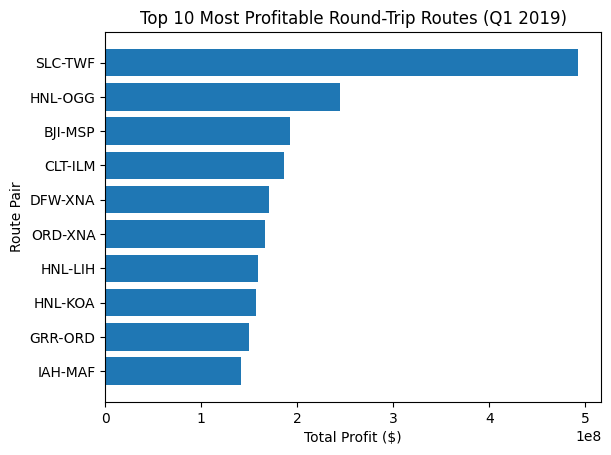

In [35]:
# Plot top 10 profitable routes
plt.figure()
plt.barh(
    top_10_profitable_routes["ROUTE_PAIR"],
    top_10_profitable_routes["PROFIT"]
)
plt.xlabel("Total Profit ($)")
plt.ylabel("Route Pair")
plt.title("Top 10 Most Profitable Round-Trip Routes (Q1 2019)")
plt.gca().invert_yaxis()  # highest profit at top
plt.show()

This chart shows the top 10 most profitable round-trip routes during Q1 2019.  
A small number of routes generate significantly higher profit than others, which helped guide the selection of recommended routes for investment.

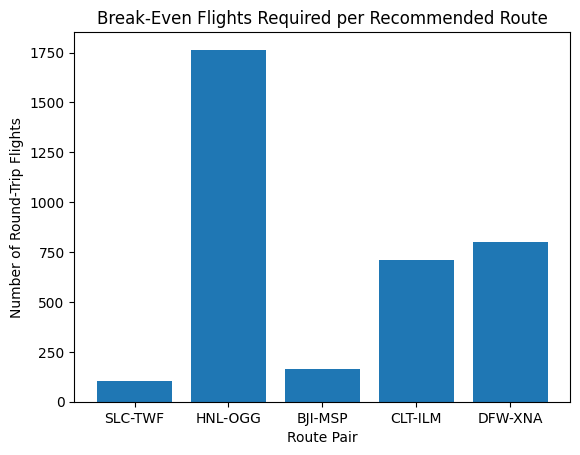

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    break_even["ROUTE_PAIR"],
    break_even["BREAK_EVEN_FLIGHTS"]
)
plt.xlabel("Route Pair")
plt.ylabel("Number of Round-Trip Flights")
plt.title("Break-Even Flights Required per Recommended Route")
plt.show()


This chart shows the number of round-trip flights required for each recommended route to recover the $90 million upfront aircraft investment.  
Routes with fewer break-even flights are more attractive because they recover the investment faster.


## Next Steps

If more time and data were available, I would incorporate additional data sources such as fuel price trends, seasonal demand patterns, and aircraft utilization rates.  
I would also analyze profitability across multiple quarters to identify long-term trends and test how sensitive profitability is to changes in costs, delays, and occupancy rates.


## Summary of Findings

In this analysis, Q1 2019 flight and ticket data were used to identify the busiest and most profitable round-trip routes between medium and large U.S. airports. Profitability was calculated using ticket revenue, baggage revenue, and detailed operating costs, including delay-related expenses. Based on the results, five routes were recommended for investment due to their strong profitability and consistent demand. A break-even analysis showed how many round-trip flights are required to recover the upfront aircraft cost, providing a clear basis for strategic decision-making.
